# Laboratorio 26 Integración de IA y computación en la niebla
## Preparación y análisis de los datos
Familiarizarse con la carga, limpieza y análisis del dataset.

In [4]:
import pandas as pd

# URL del dataset de calidad de vino blanco (UCI Machine Learnin Repository)

url ='https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv'

# Cargar el dataset
# Este dataset utiliza ';' como separador y no tiene nombre de columnas en la primera fila.

data = pd.read_csv(url, sep=';')

# Mostrar las primeras filas del dataset    
print("Primeras lineas del dataset:")   
print(data.head())

# Mostrar información del dataset
print("\nInformación del dataset:")
print(data.info())

print("\nDescripción del dataset:")
print(data.describe())


Primeras lineas del dataset:
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.0              0.27         0.36            20.7      0.045   
1            6.3              0.30         0.34             1.6      0.049   
2            8.1              0.28         0.40             6.9      0.050   
3            7.2              0.23         0.32             8.5      0.058   
4            7.2              0.23         0.32             8.5      0.058   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 45.0                 170.0   1.0010  3.00       0.45   
1                 14.0                 132.0   0.9940  3.30       0.49   
2                 30.0                  97.0   0.9951  3.26       0.44   
3                 47.0                 186.0   0.9956  3.19       0.40   
4                 47.0                 186.0   0.9956  3.19       0.40   

   alcohol  quality  
0      8.8        6  
1      9.5   

## Limpieza y preprocesamiento de Datos.

Verificación de valores nulos y duplicados

In [5]:
# Comprobar valores nulos
print("Valores nulos por columna: ")
print(data.isnull().sum())

# Verificar duplicados
duplicates = data.duplicated().sum()
print(f"Filas duplicadas: {duplicates}")

Valores nulos por columna: 
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64
Filas duplicadas: 937


## Análisis exploratorio de Datos (EDA)

### Distribución de variables:
Visualizar la distribución de las variables más importantes con histogramas, por
ejemplo la acidez fija, acidez volátil, alcohol, etc. Esto permitirá entender la naturaleza
de los datos (distribuciones sesgadas, variables dominantes, etc.).

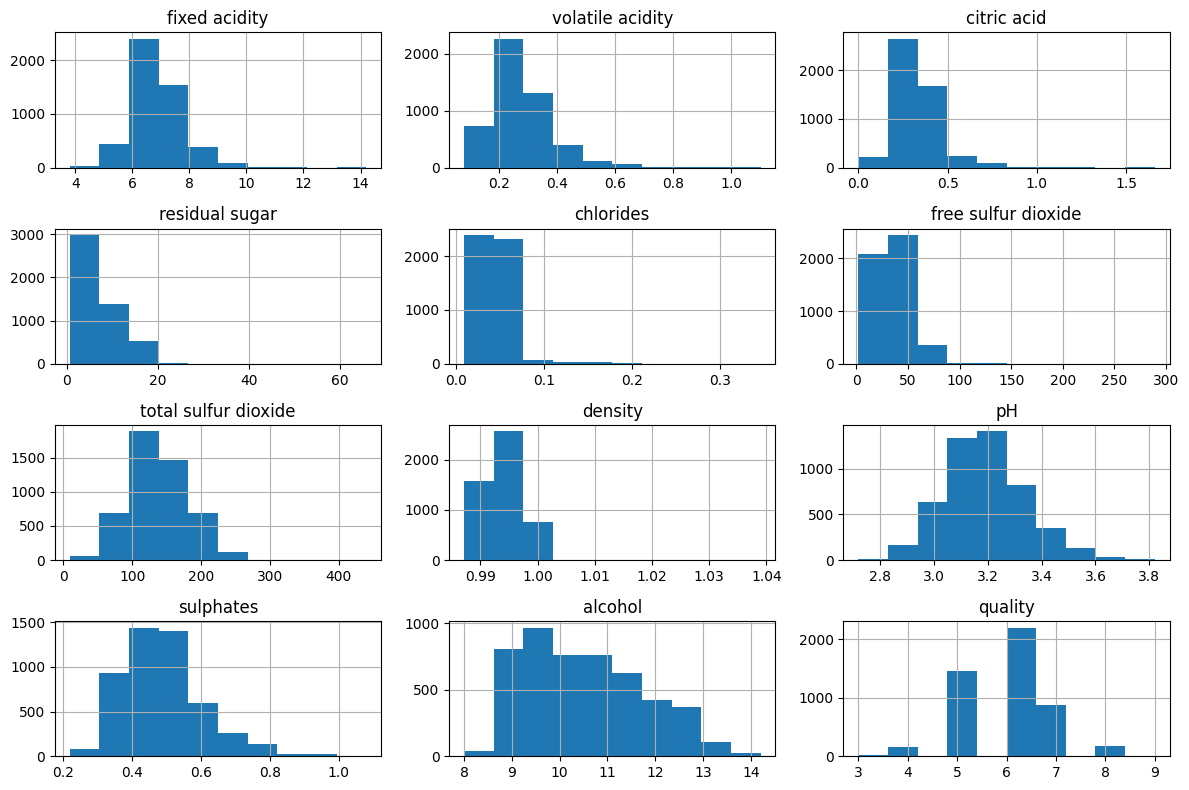

In [6]:
import matplotlib.pyplot as plt

data.hist(figsize=(12, 8))
plt.tight_layout()
plt.show()



## RElación con la calidad del vino:
Como la variable ‘quality’ es el objetivo principal (variable dependiente), analizar la correlación
entre esta y las variables independientes. Por ejemplo, una matriz de correlación para
identificar qué características se relacionan más fuertemente con la calidad del vino.

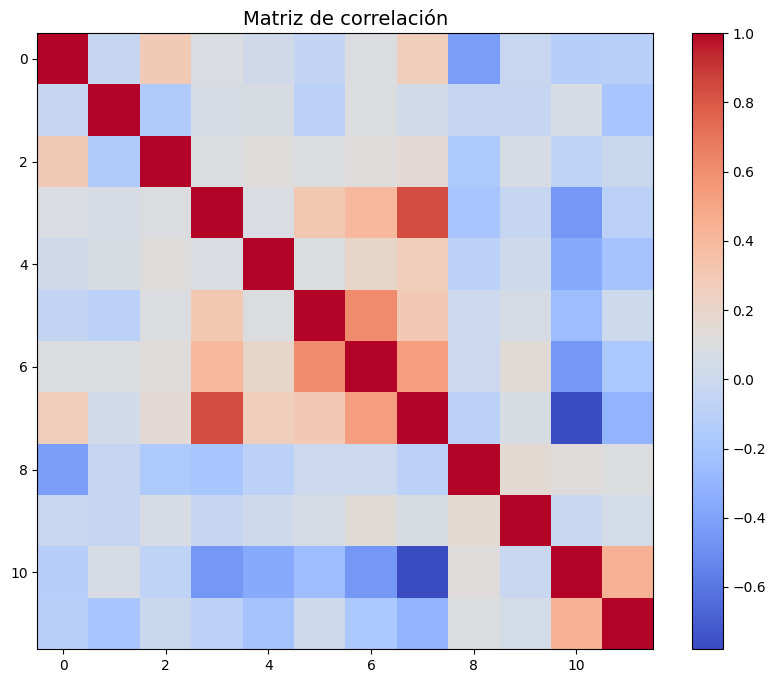

Correlación con la variable 'quality':
quality                 1.000000
alcohol                 0.435575
pH                      0.099427
sulphates               0.053678
free sulfur dioxide     0.008158
citric acid            -0.009209
residual sugar         -0.097577
fixed acidity          -0.113663
total sulfur dioxide   -0.174737
volatile acidity       -0.194723
chlorides              -0.209934
density                -0.307123
Name: quality, dtype: float64


In [9]:
plt.figure(figsize=(10, 8))
correlation = data.corr()
plt.imshow(correlation, cmap='coolwarm', interpolation='nearest')
plt.colorbar()
plt.title("Matriz de correlación", fontsize=14)
plt.show()

# Imprimir la correlación con la variable 'quality'
print("Correlación con la variable 'quality':")
print(correlation['quality'].sort_values(ascending=False))



## Creación de un modelo ligero de Machine Learning
Como la variable ‘quality’ es el objetivo principal (variable dependiente), analizar la correlación
entre esta y las variables independientes. Por ejemplo, una matriz de correlación para
identificar qué características se relacionan más fuertemente con la calidad del vino


In [10]:
features = ['alcohol', 'pH', 'sulphates']
X = data[features]
y = data['quality']

## División de Datos de entrenamiento y prueba
Separar el dataset en conjuntos de entrenamiento (para ajustar el modelo) y prueba (para
evaluar su rendimiento en datos no vistos).

In [12]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Entrenamiento del modelo inicial de Machine learning
Entrenar un modelo de tipo Random Forest o Regresión Logística, ya que son modelos
relativamente sencillos de implementar. El objetivo es contar con un punto de partida antes de
optimizar.


In [13]:
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(n_estimators=50, max_depth=5, random_state=42)
model.fit(X_train, y_train)


,n_estimators,50
,criterion,'squared_error'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## Evaluación del modelo inicial

Evaluar el rendimiento del modelo utilizando métricas
adecuadas. En el caso de calidad del vino, podría emplearse el Error Cuadrático Medio
(MSE) o el Coeficiente de Determinación (R²) si se considera el problema como una
regresión. Para clasificación, se pueden usar accuracy, F1-score, etc. Aquí se asume
regresión.

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE del modelo inicial: {mse}")
print(f"R² del modelo inicial: {r2}")


MSE del modelo inicial: 0.5739008788291583
R² del modelo inicial: 0.2589789729182371
